<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-3-lenamackiewicz/blob/main/Lab03_Klasyfikacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold


**Zad 1 - badanie i podział danych**


In [2]:
data = pd.read_csv("/content/Heart_disease_cleveland_new.csv")

In [3]:
data.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
5,56,1,1,120,236,0,0,178,0,0.8,0,0,1,0
6,62,0,3,140,268,0,2,160,0,3.6,2,2,1,1
7,57,0,3,120,354,0,0,163,1,0.6,0,0,1,0
8,63,1,3,130,254,0,2,147,0,1.4,1,1,3,1
9,53,1,3,140,203,1,2,155,1,3.1,2,0,3,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


Opis danych:

**Age**: Patients Age in years (Numeric)

**Sex**: Gender (Male : 1; Female : 0) (Nominal)

**cp**: Type of chest pain experienced by patient. This term categorized into 4 category.
0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)

**trestbps**: patient's level of blood pressure at resting mode in mm/HG (Numerical)

**chol**: Serum cholesterol in mg/dl (Numeric)

**fbs**: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)

**restecg**: Result of electrocardiogram while at rest are represented in 3 distinct values
0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)

**thalach**: Maximum heart rate achieved (Numeric)

**exang**: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)

**oldpeak**: Exercise induced ST-depression in relative with the state of rest (Numeric)

**slope**: ST segment measured in terms of slope during peak exercise
0: up sloping; 1: flat; 2: down sloping(Nominal)

**ca**: The number of major vessels (0–3)(nominal)

**thal**: A blood disorder called thalassemia
0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)

**target**: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.

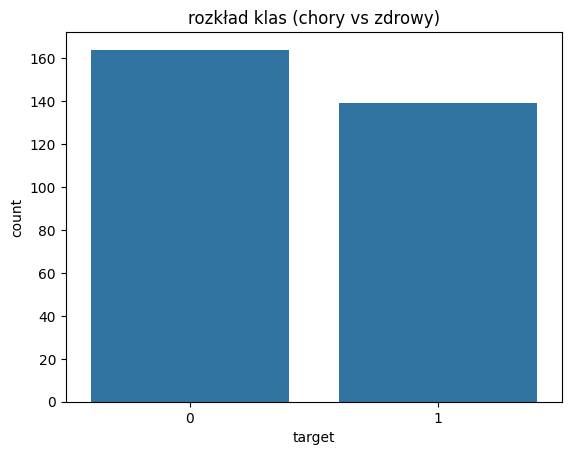

In [6]:
sns.countplot(x='target', data = data)
plt.title("rozkład klas (chory vs zdrowy)")
plt.show()

In [7]:
Y = data['target']
X = data.drop('target', axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# X_train.info()
# X_test.info()


**Zad 2 - trenowanie modelu**

In [8]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

**Zad 3 - ocena działania modelu**

In [9]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



interpetacja:

 - Czułość (Recall): Odpowiada na pytanie: "Spośród wszystkich faktycznie chorych pacjentów, ilu model poprawnie zdiagnozował?".

- Precyzja (Precision): "Spośród wszystkich pacjentów, których model uznał za chorych, ilu faktycznie jest chorych?".

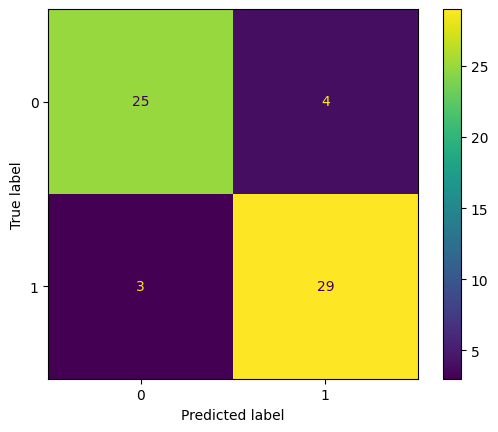

In [18]:
#MACIERZ POMYŁEK
cm = confusion_matrix(Y_test, Y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

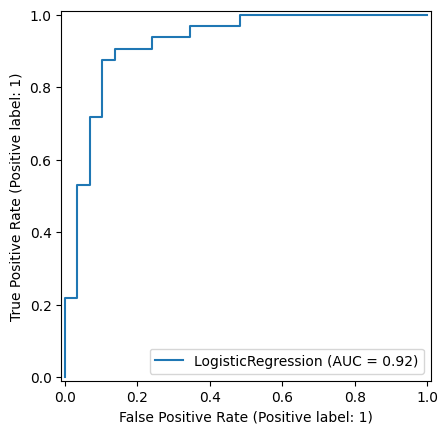

In [11]:
#KRZYWA ROC
RocCurveDisplay.from_estimator(model, X_test, Y_test)
plt.show()

**Zad 4 - jak na działanie modelu wpływają standaryzacja i normalizacja danych?**

In [15]:
print("Wynik oryginalny:", accuracy_score(Y_test, Y_pred))

#STANDARYZACJA

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

model_std = LogisticRegression(max_iter=1000, random_state=42)
model_std.fit(X_train_std, Y_train)
Y_pred_std = model_std.predict(X_test_std)
print("Wynik po standaryzacji:", accuracy_score(Y_test, Y_pred_std))

#NORMALIZACJA

scaler_norm = MinMaxScaler()
X_train_norm = scaler_norm.fit_transform(X_train)
X_test_norm = scaler_norm.transform(X_test)

model_norm = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_norm, Y_train)
Y_pred_norm = model_norm.predict(X_test_norm)
print("Wynik po normalizacji:", accuracy_score(Y_test, Y_pred_norm))

Wynik oryginalny: 0.8852459016393442
Wynik po standaryzacji: 0.8852459016393442
Wynik po normalizacji: 0.8852459016393442


**Zad 5 - wypływ parametrów na działanie modelu**


C=0.001, Dokładność: 0.4754, Liczba potrzebnych iteracji: 1
C=0.01, Dokładność: 0.5082, Liczba potrzebnych iteracji: 16
C=0.1, Dokładność: 0.9016, Liczba potrzebnych iteracji: 16
C=1, Dokładność: 0.8852, Liczba potrzebnych iteracji: 26
C=10, Dokładność: 0.8852, Liczba potrzebnych iteracji: 22
C=100, Dokładność: 0.8852, Liczba potrzebnych iteracji: 17


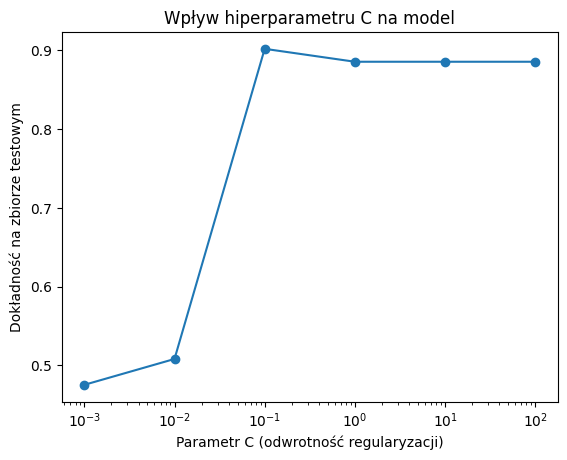

In [13]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
scores = []

for c in C_values:
    model = LogisticRegression(penalty='elasticnet', solver='saga', C=c, l1_ratio=0.5, max_iter=2000)
    model.fit(X_train_std, Y_train)
    score = model.score(X_test_std, Y_test)
    scores.append(score)
    print(f"C={c}, Dokładność: {score:.4f}, Liczba potrzebnych iteracji: {model.n_iter_[0]}")

plt.plot(C_values, scores, marker='o')
plt.xscale('log')
plt.xlabel('Parametr C (odwrotność regularyzacji)')
plt.ylabel('Dokładność na zbiorze testowym')
plt.title('Wpływ hiperparametru C na model')
plt.show()

**Zad 6 - Zachowanie modelu przy zastosowaniu walidacji krzyżowej**

In [19]:
folds = [2, 5, 10]
results = []

for k in folds:
    # Zwykłe K-Fold (bez stratyfikacji)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_kf = cross_val_score(model_std, X, Y, cv=kf)

    # Stratyfikowane K-Fold (zachowuje proporcje klas)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores_skf = cross_val_score(model_std, X, Y, cv=skf)

    results.append({
        'K': k,
        'Średnia KFold': np.mean(scores_kf),
        'Odch. std KFold': np.std(scores_kf),
        'Średnia Stratified': np.mean(scores_skf),
        'Odch. std Stratified': np.std(scores_skf)
    })

df_results = pd.DataFrame(results)
print(df_results)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

    K  Średnia KFold  Odch. std KFold  Średnia Stratified  \
0   2       0.841582         0.000523            0.831627   
1   5       0.838142         0.029130            0.834863   
2  10       0.831613         0.060133            0.827849   

   Odch. std Stratified  
0              0.017057  
1              0.046968  
2              0.065338  


**Pytania pomocnicze**
1. Podział na zbiór treningowy i testowy jest kluczowy, aby algorytm nie nauczył się dopasowań "na pamięć" (overfitting). Na zbiorze testowym można sprawdzić jego skuteczność. Poprawny podział: losowość, stratyfikacja, brak wycieku danych (ze zbioru testowego do treningowego.
2. Metody:
- fit - algorytm "uczy się" na danych, obliczając odpowiednie parametry, ale nie modyfikuje ich
- transform - algorytm używa wyliczonych wcześniej parametrów (fit) i przekształca dane, zwracając nową tablicę
- fit_transform - wykonuje oba kroki równocześnie (stosowane ze względów wydajnościowych)
3. Regresja logistyczna: najpierw działa podobnie do regresji liniowej, następnie przepuszcza wynik przez nieliniową funkcję aktywacji (sigmoidę), która "spłaszcza" wyniki do przedziału (0, 1) - prawdopodobieństwo przynależności do danej klasy (przy klasyfikacji binarnej)
- funkcja kosztu: Log-Loss
4. Parametry klasyfikatoru Logistic Regression:
- wewnętrzne parametry (wagi): dla n atrybutów model uczy się n+1 wag (+1 - bias)
- hiperparametry: C - odwrotność (w bibliotece scikit-learn) siły regularyzacji, mniejsze wartości oznaczają silniejszą regularyzację (dążenie do mniejszych wartości wag); Penalty - typ nakladanej kary na zbyt duże wagi (L2 - wartości są zmniejszane, często bardzo bliskie zeru, L1 - zeruje wagi mniej istotnych cech); Max_iter - maksymalna liczba iteracji
5. Miary jakości:
- precyzja (precision): TP / (TP + FP). Ważna, gdy koszt "fałszywego alarmu" (FP) jest wysoki
- czułość (recall): TP / (TP + FN). Ważna, gdy koszt "przeoczenia przypadku" (FN) jest wysoki
- Przykłady: filtr antyspamowy – lepiej przepuścić jeden spam do skrzynki odbiorczej (spadek czułości), niż usunąć oznaczając jako spam ważnego maila od szefa (niska precyzja); badania przesiewowe na raka (albo zbiór Heart Disease) – lepiej wezwać zdrowego pacjenta na dodatkowe, niepotrzebne badania (niska precyzja), niż zignorować śmiertelną chorobę i odesłać chorego pacjenta do domu (niska czułość).
6. Krzywa ROC (Receiver Operating Characteristic) - wykres pokazujący kompromis pomiędzy czułością a wskaźnikiem fałszywych alarmów dla każdego możliwego progu klasyfikacji (0-1)